<img src="https://hilpisch.com/tpq_logo_bic.png" width="20%" align="right">

# Python & AI in Asset Management
## Chapter 6 · Black–Litterman and Bayesian Portfolio Construction

&copy; Dr. Yves J. Hilpisch<br>
AI-Powered by GPT 5.1<br>
The Python Quants GmbH | https://tpq.io<br>
https://hilpisch.com | https://linktr.ee/dyjh


## Notebook Goals
We implement the Black–Litterman workflow:
- compute equilibrium (implied) returns from a benchmark,
- encode absolute and relative views,
- blend priors and views into posterior returns, and
- compare resulting portfolios/diagnostics.


### Getting Help While Using Black–Litterman
- **Chapter 4** for mean–variance background.
- **Appendix A** for the derivation of the update formulas.
- **Appendix B** to refresh NumPy array manipulations.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8")
plt.rcParams.update({"font.family": "serif", "figure.dpi": 300})

DATA_PATH = Path("../data/pyaiam_eod.csv")
if not DATA_PATH.exists():
    DATA_PATH = "https://hilpisch.com/pyaiam_eod.csv"
RISK_AVERSION = 3.0   # 设 3.0 就是标准偏保守、正常机构常用风险厌恶。
TAU = 0.05            # 市场均衡收益 π 的不确定性，prior uncertainty。τ (tau) 越大 → 越弱化市场、放大你自己的主观观点。

## 1. Inputs: Returns, Covariance, Benchmark Weights
We build annualized statistics for six assets and assume equal benchmark weights.

In [2]:
assets = ["AAPL", "NVDA", "JPM", "SPY", "GLD", "TLT"]
prices = pd.read_csv(DATA_PATH, parse_dates=["Date"]).set_index("Date").sort_index()
prices = prices.ffill()
log_rets = np.log(prices / prices.shift(1)).dropna()[assets]
mean_returns = log_rets.mean() * 252
cov_matrix = log_rets.cov() * 252
w_benchmark = np.repeat(1 / len(assets), len(assets))
mean_returns

,0
AAPL,0.235262
NVDA,0.544556
JPM,0.182138
SPY,0.135787
GLD,0.133970
TLT,-0.003054


## 2. Equilibrium (Implied) Returns 如果市场组合是最优组合，那隐含要求的收益率是多少？
第一篇：  
Black–Litterman starts by inferring returns that make the benchmark optimal under mean–variance preferences.  

w = 市场已经处于均衡，市场组合（market portfolio weights）；   
Σ = 这些资产风险之间如何互相影响，是风险结构（risk structure）；  
Σw = 整个组合的风险暴露方向。  

再乘：
λ（风险价格）即市场要求的收益补偿。  

综上，pi = RISK_AVERSION * cov_matrix.values @ w_benchmark  


第二篇：  
π（市场观点）：“市场认为收益应该是这样”，是风险的价格结构；  
TAU：“市场这个观点有多不可靠”，它是在进入 Bayesian 更新时，Black-Litterman 进一步说：“虽然 π 是市场均衡收益，但它不一定完全正确。”  
Ω：“你自己的观点有多不可靠”；  
Bayesian 更新：market + views → posterior returns。


In [3]:
# 市场隐含均衡收益率 π（implied equilibrium returns）市场认为的合理收益 = 风险厌恶 × 协方差矩阵 × 基准权重

pi = RISK_AVERSION * cov_matrix.values @ w_benchmark   # * = 逐元素相乘（element-wise）;@ = 矩阵乘法（matrix multiplication / 点积）
pd.Series(pi, index=assets)

,0
AAPL,0.116970
NVDA,0.213031
JPM,0.087858
SPY,0.082177
GLD,0.014557
TLT,0.000603


## 3. Encode Investor Views
We mix one absolute view (AAPL +1&#37; vs. cash) and one relative view (NVDA outperform GLD by 50 bps).  
* 观点矩阵 P 对哪些资产表达观点,这是相对观点；
* 观点收益 Q, absolute view（绝对观点）；
* 观点不确定性 Ω，主观观点的不确定性

In [4]:
P = np.array(                      # 行表示观点，列表示资产。
    [
        [1, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, -1, 0],
    ]
)
Q = np.array([0.01, 0.005])
OMEGA = np.diag([0.0004, 0.0009])   # 这里假设了观点之间是相互独立的，否则还有协方差。

## 4. Black–Litterman Update Function
The function below returns posterior means and covariances.

In [5]:
def black_litterman(cov: np.ndarray,      # 资产之间如何联动
                    tau: float,           # 市场均衡的不确定性缩放
                    pi_vec: np.ndarray,   # 市场隐含收益：市场prior belief
                    P: np.ndarray,
                    Q: np.ndarray,
                    omega: np.ndarray     # 观点误差协方差
                    ):
    tau_cov = tau * cov                      # cov可以看作风险结构的云☁️；tau控制了云☁️的大小。tau_cov表示π 有多"不可信"。
    inv_tau_cov = np.linalg.inv(tau_cov)     # 表示π 有多"可信"，是市场 prior view 在“资产收益空间”的 precision。
    middle = P.T @ np.linalg.inv(omega) @ P  # np.linalg.inv(omega): 每个观点有多可信; P 把资产映射成观点；Pᵀ把观点映射成资产。总体，是观点对资产收益的precision。
    posterior_cov = np.linalg.inv(inv_tau_cov + middle)  # 把市场+观点的“信息总量”转换成“收益率的不确定性结构”。


    # posterior = covariance × (market precision term + view precision term)
    posterior_mean = posterior_cov @ (
        inv_tau_cov @ pi_vec + P.T @ np.linalg.inv(omega) @ Q  # P：把资产 → 变成观点；Q：观点的结果数值。
        )
    return posterior_mean, posterior_cov

post_mean, post_cov = black_litterman(
    cov_matrix.values,
    TAU,
    pi,
    P,
    Q,
    OMEGA,
)
pd.Series(post_mean, index=assets)

,0
AAPL,0.016057
NVDA,0.036728
JPM,0.037899
SPY,0.024353
GLD,0.023098
TLT,0.009607


## 5. Compare Prior vs. Posterior Inputs
We chart implied vs. posterior returns to see how views shift expectations.

In [6]:
comparison = pd.DataFrame({"pi": pi, "posterior": post_mean}, index=assets)
comparison

,pi,posterior
AAPL,0.116970,0.016057
NVDA,0.213031,0.036728
JPM,0.087858,0.037899
SPY,0.082177,0.024353
GLD,0.014557,0.023098
TLT,0.000603,0.009607


## 6. Posterior Portfolio Illustration
We compute max-Sharpe weights based on posterior means and compare with benchmark weights.

In [7]:
cov_inv = np.linalg.inv(post_cov)
ones = np.ones(len(assets))

# 来源：covariance × weights = excess return，即 市场要求：你承担的风险（Σw），必须刚好匹配你想要的收益（μ - r_f）。
# 由此推出：weights = cov_inv @ excess return.
posterior_weights = cov_inv @ (post_mean - 0.02 * ones)  # cov越大的，cov_inv越小，也就说风险越大，weights越少配；
                                                         # post_mean越大的，收益越高，weights越多配。
posterior_weights /= posterior_weights.sum()
weights_df = pd.DataFrame(
    {
        "Benchmark": w_benchmark,
        "Posterior": posterior_weights,
    },
    index=assets,
)
weights_df

,Benchmark,Posterior
AAPL,0.166667,1.083113
NVDA,0.166667,-1.429790
JPM,0.166667,-0.525551
SPY,0.166667,0.500528
GLD,0.166667,0.669085
TLT,0.166667,0.702614


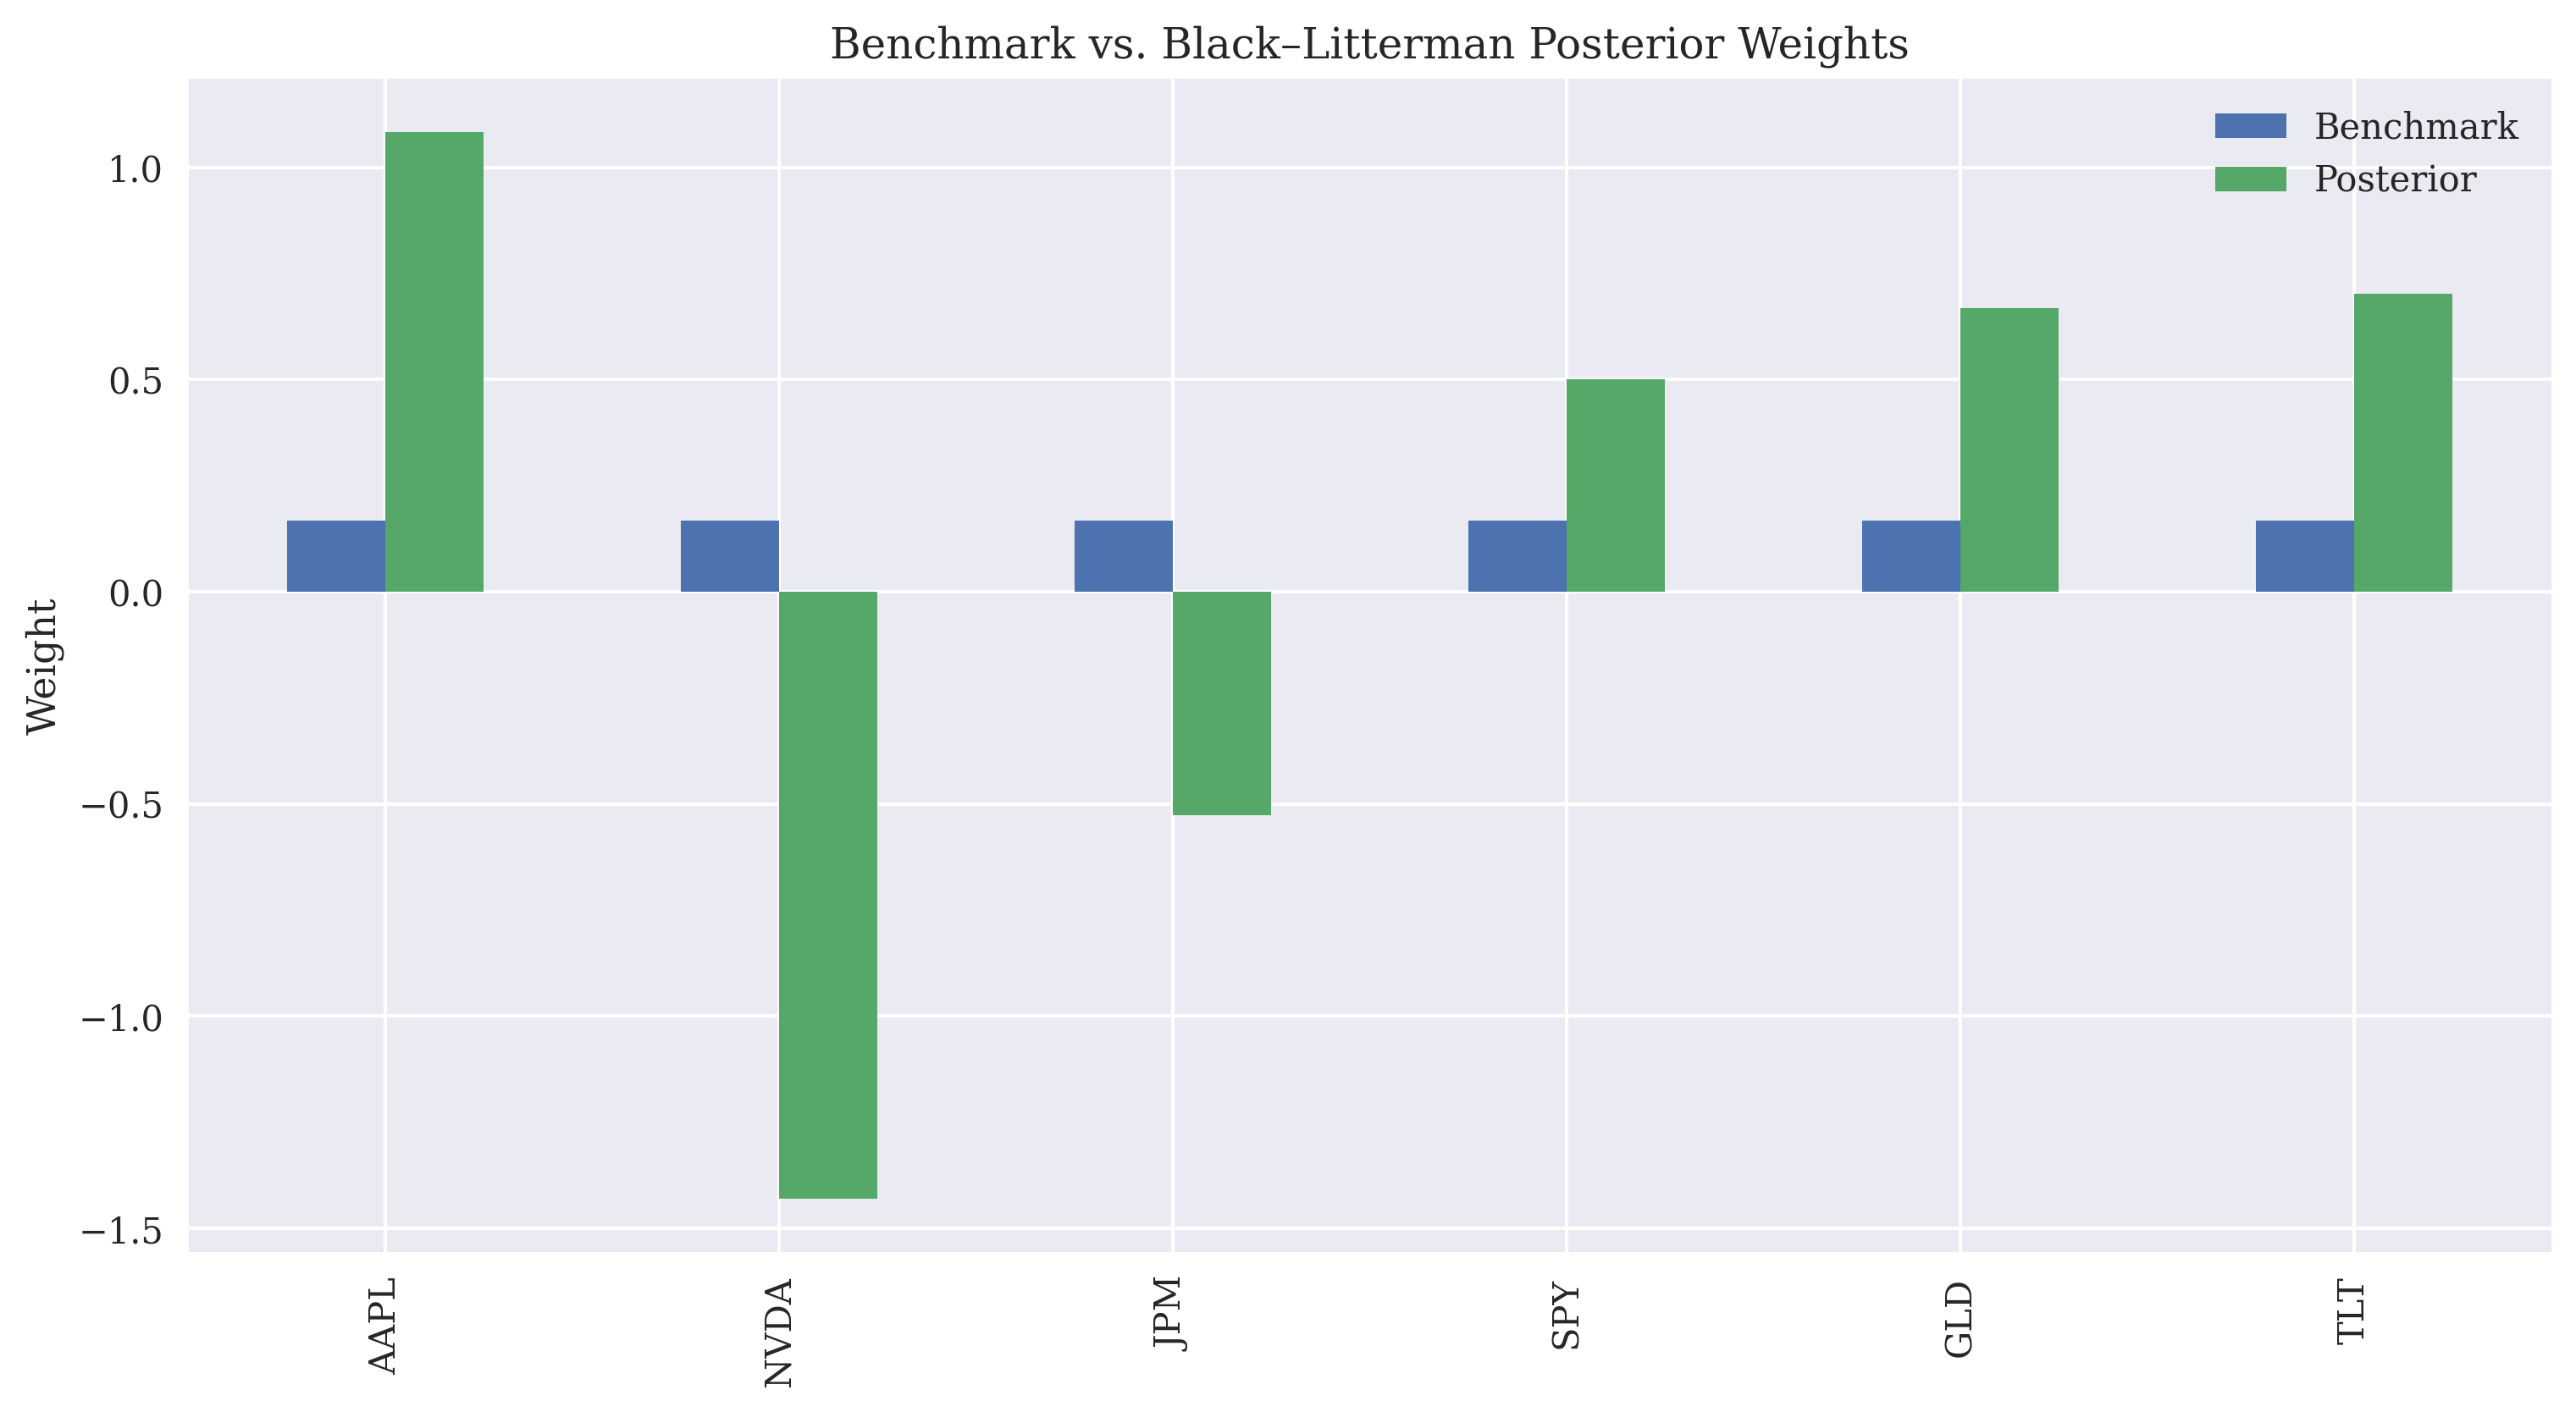

In [8]:
ax = weights_df.plot(kind="bar", figsize=(12, 6))
ax.set_ylabel("Weight")
ax.set_title("Benchmark vs. Black–Litterman Posterior Weights")
plt.show()

## 7. Posterior Frontier Snapshot
Monte Carlo sampling conveys how the posterior pushes the efficient frontier.

We overlay Monte Carlo samples based on the equilibrium prior (pi) and the posterior to visualize how views reshape the feasible set.

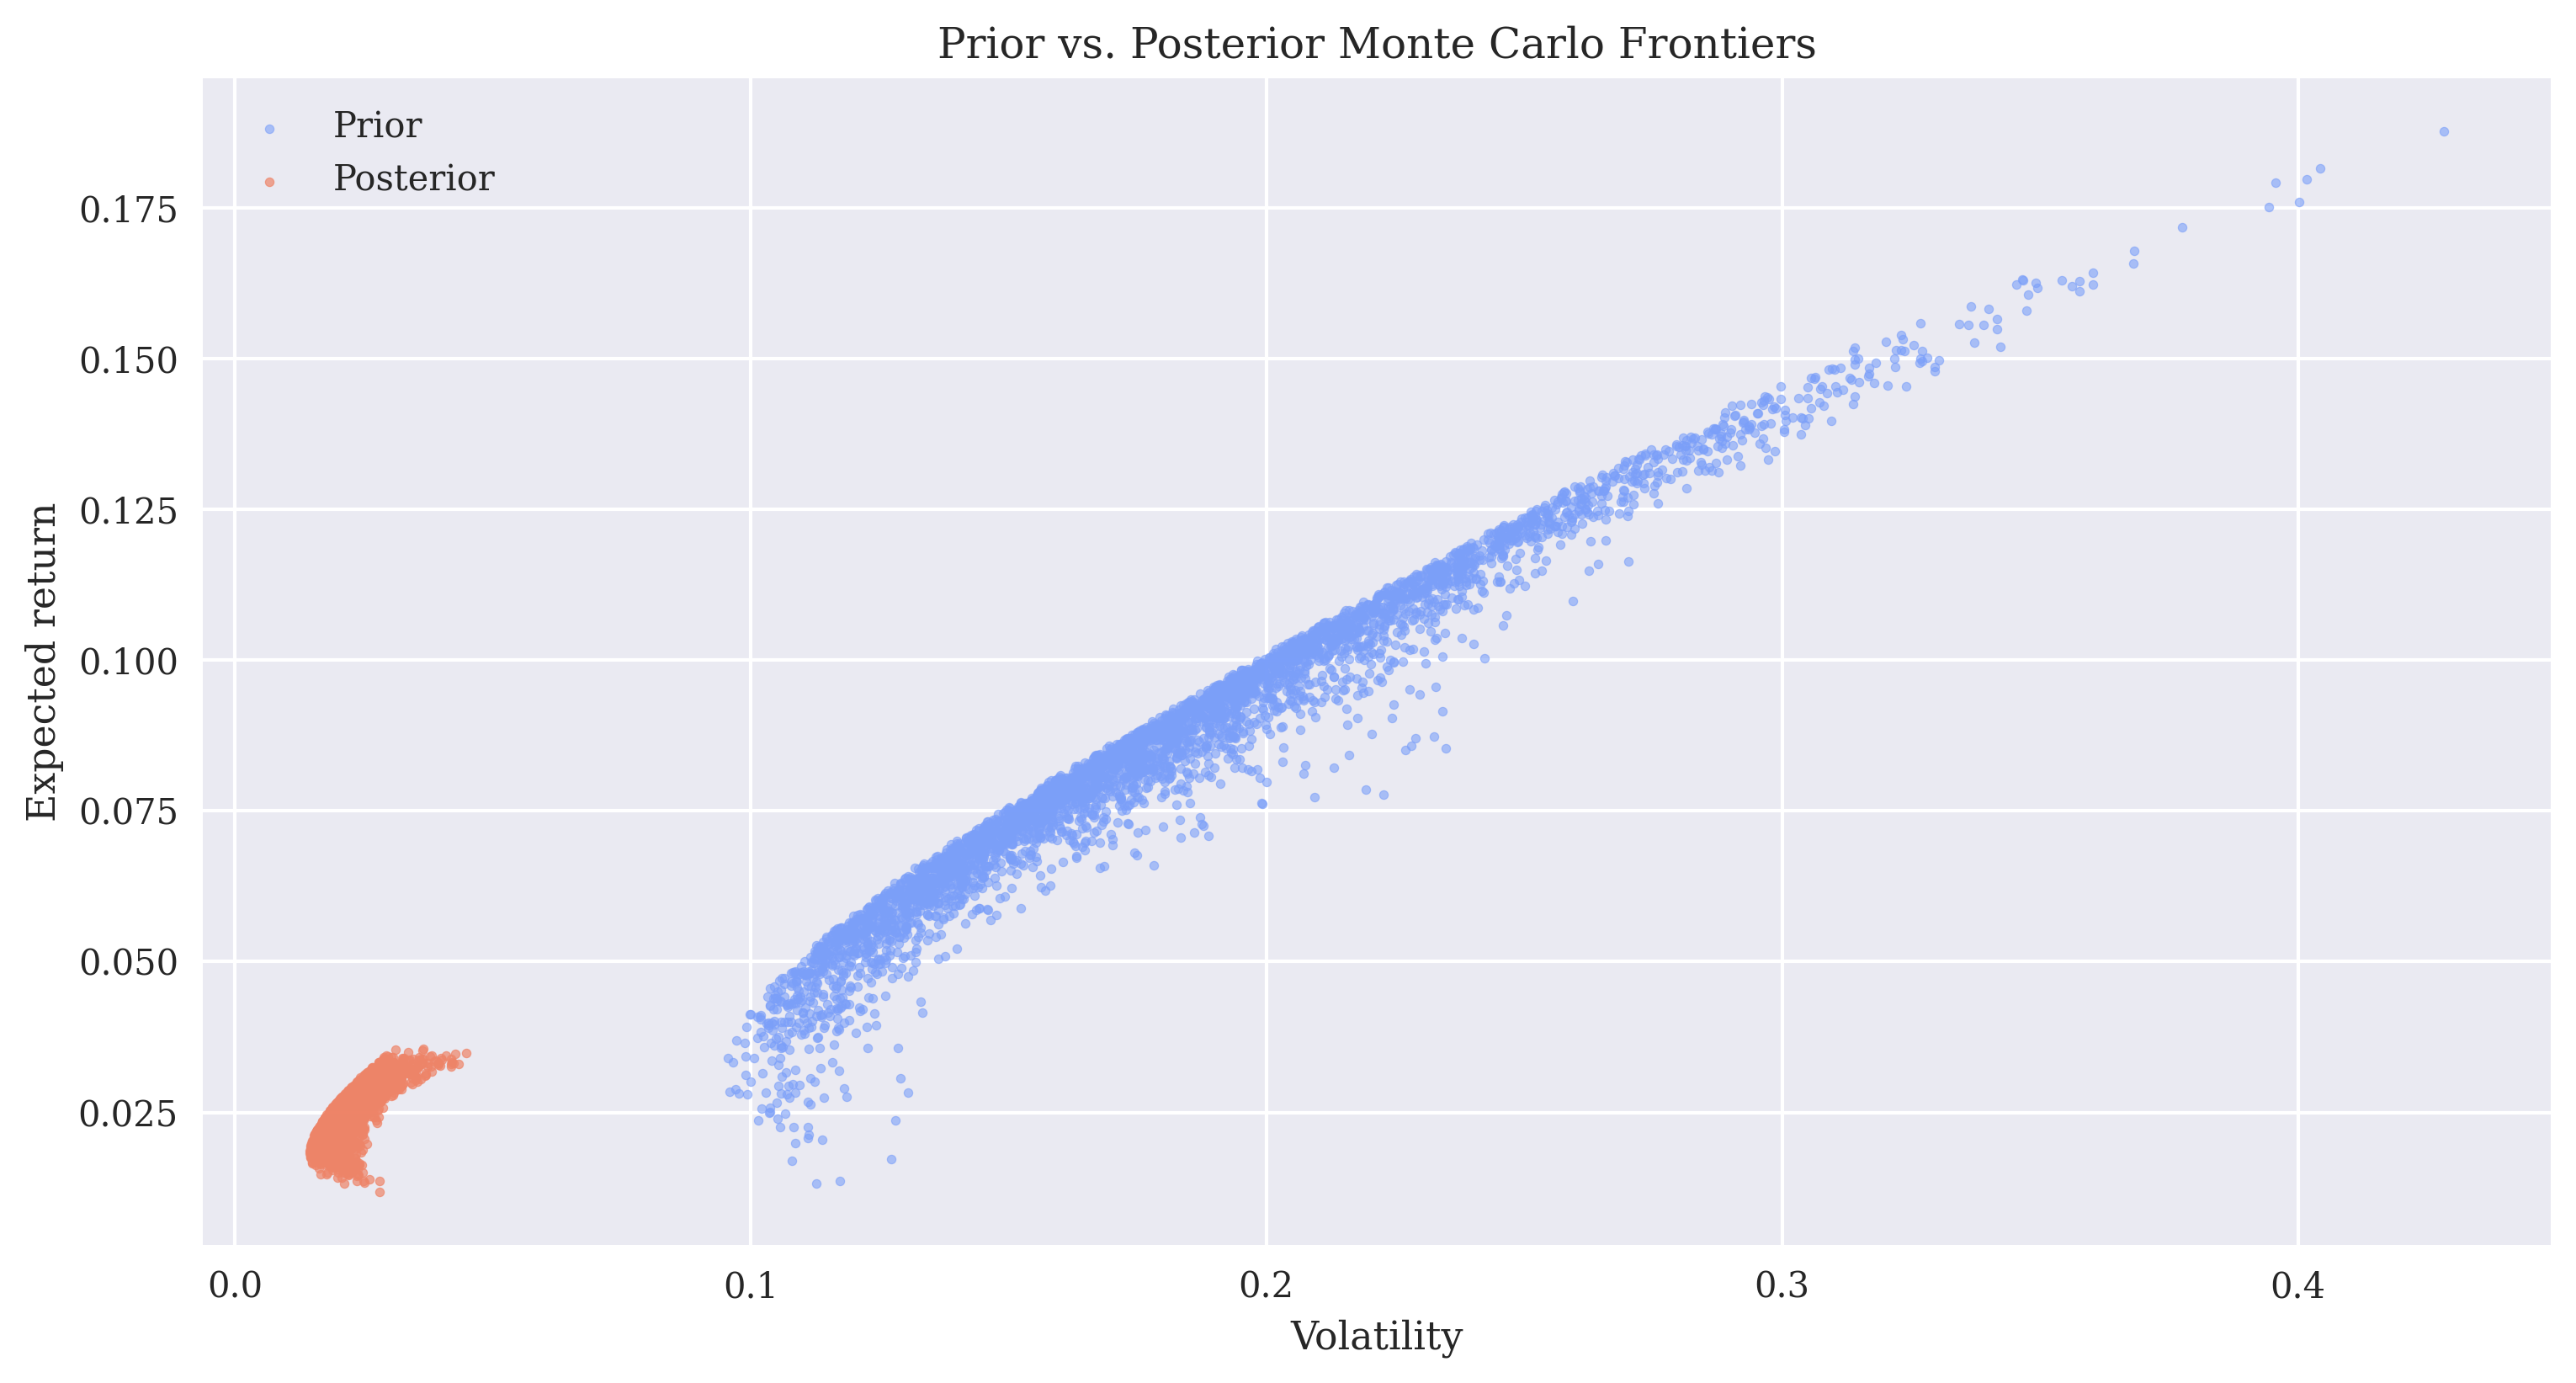

In [9]:
rng = np.random.default_rng(123)
n_ports = 4000
weights = rng.dirichlet(np.ones(len(assets)), size=n_ports)
prior_returns = weights @ pi
prior_vols = np.sqrt(np.einsum("bi,ij,bj->b", weights, cov_matrix.values, weights))
post_returns = weights @ post_mean
post_vols = np.sqrt(np.einsum("bi,ij,bj->b", weights, post_cov, weights))
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(
    prior_vols,
    prior_returns,
    s=6,
    alpha=0.6,
    color=plt.cm.coolwarm(0.2),
    label="Prior",
)
ax.scatter(
    post_vols,
    post_returns,
    s=6,
    alpha=0.7,
    color=plt.cm.coolwarm(0.8),
    label="Posterior",
)
ax.set_xlabel("Volatility")
ax.set_ylabel("Expected return")
ax.set_title("Prior vs. Posterior Monte Carlo Frontiers")
ax.legend()
plt.show()

## 8. Exercises
### Exercise 1 – View Confidence Sweep
Vary the diagonal of <code>OMEGA</code> to see how posterior means react.
<details><summary>Hint</summary>
Multiply <code>OMEGA</code> by scalars (0.25, 1, 4) and recompute <code>posterior_mean</code>.
</details>

### Exercise 2 – Alternative Benchmark
Swap <code>w_benchmark</code> for market-cap weights proportional to the last price and repeat the workflow.
<details><summary>Hint</summary>
Use <code>prices.iloc[-1]</code> as a proxy for cap weight, normalize, and rebuild <code>pi</code>.
</details>

### Exercise 3 – Frontier Comparison
Plot Monte Carlo clouds for both prior (<code>pi</code>) and posterior means on the same axes.
<details><summary>Hint</summary>
Reuse the Chapter 4 sampling function and overlay scatter plots with different colors.
</details>


## 9. Takeaways for Chapter 6
- Black–Litterman tempers mean estimates before optimization.
- Encoding views as matrices keeps the workflow auditable.
- Posterior outputs feed directly into the Chapter 4 optimization toolkit.


<img src="https://hilpisch.com/tpq_logo_bic.png" width="20%" align="right">